# 01 Data Cleaning


In [19]:
!pip install pandas matplotlib numpy openpyxl


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

In [21]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_excel('../data/raw/data_11-03_10-04.xlsx', sheet_name='Sheet1')
df.head()

,timestamp,FT-201,FT-801,FT-901,Mode,PT-901,PT-902,LS-901,PT-903,TT-901,TT-902,TT-903,TT-904,VSD-901_CORRENT,VSD-901_POWER,VSD-901_RPM,VSD-901_SPEED
0,2026-03-11 10:15:00,640.581604,312.695312,520.833313,8,-0.494430,0.024161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-11 10:16:00,643.880249,311.718750,274.348969,8,-0.723380,0.011357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-11 10:17:00,650.651062,314.624023,187.825516,9,-0.811921,0.007017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-11 10:18:00,642.664917,320.190430,881.510437,9,-0.160229,0.046369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-11 10:19:00,642.664917,318.310547,340.950531,9,-0.655020,0.014829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
print("Nr of Observations before Cleaning: ", len(df))

# Change the starting point of our data. Start where we data from all features
df["timestamp"]     = pd.to_datetime(df["timestamp"])
df                  = df.sort_values("timestamp").reset_index(drop=True)
first_complete_idx  = df.notna().all(axis=1).idxmax()
df_cleaned          = df.iloc[first_complete_idx:].reset_index(drop=True)

# Remove the frozen PT-903 sensor episode identified during EDA
frozen_mask = np.isclose(df_cleaned["PT-903"], -2.896296, atol=1e-4)
print(f"Removing {frozen_mask.sum()} observations from the frozen PT-903 episode")
df_cleaned = df_cleaned[~frozen_mask].reset_index(drop=True)

print("Nr of Observations after Cleaning: ", len(df_cleaned))

Nr of Observations before Cleaning:  40773
Removing 294 observations from the frozen PT-903 episode
Nr of Observations after Cleaning:  38881


In [23]:
#Check if we hava gaps in the midle of the dataset
df_cleaned["time_diff"] = df_cleaned["timestamp"].diff()
gaps = df_cleaned[df_cleaned["time_diff"] > pd.Timedelta(minutes=1)]

if not gaps.empty:
    total_time_lost = gaps["time_diff"].sum()
    print(f"Total time missing: {total_time_lost}")
    print(f"Nr of jumps found: {len(gaps)}")

Total time missing: 1 days 20:59:01.430000
Nr of jumps found: 79


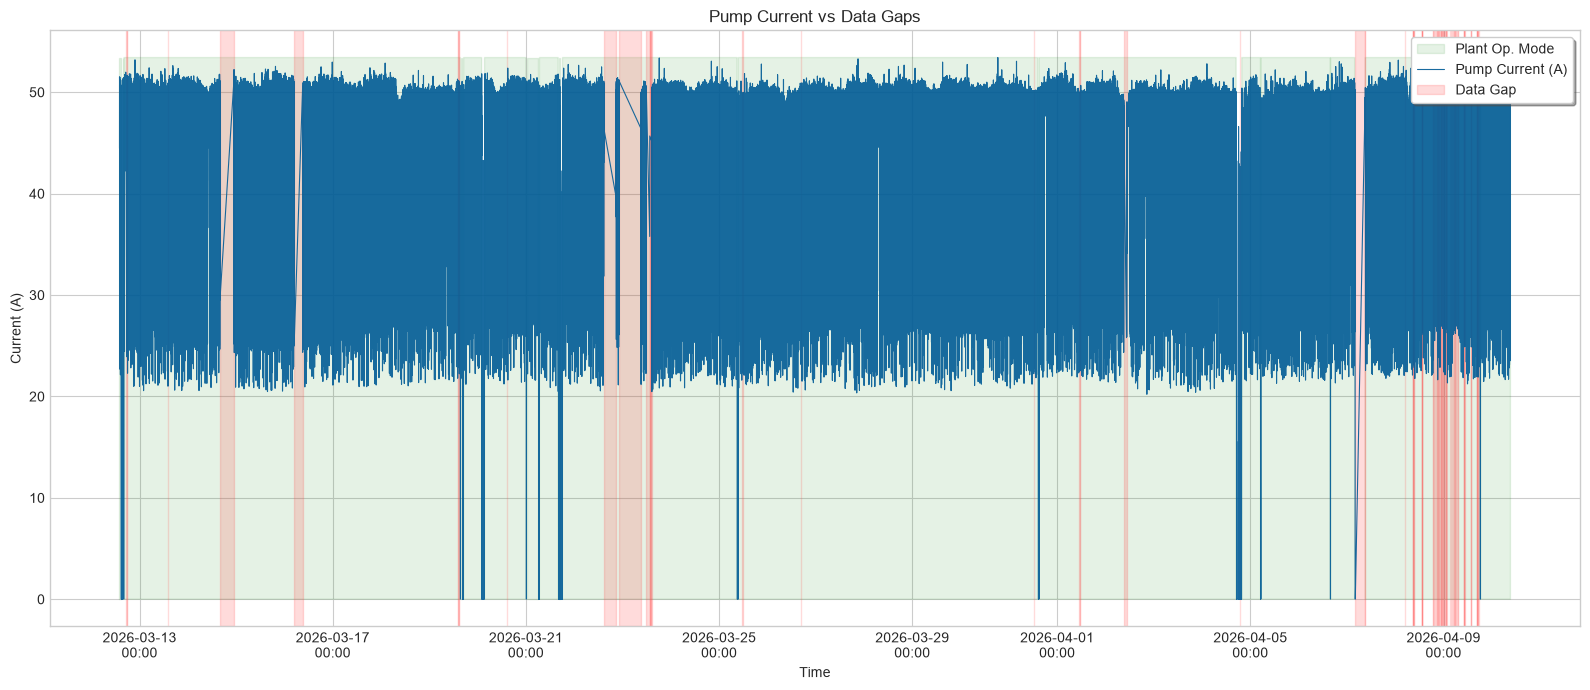

In [24]:
# Plot when the pump was turned off, and cross this information with the gaps in our dataset and the Run Mode of the Power Plant

plt.style.use('seaborn-v0_8-whitegrid') # or 'ggplot'
fig, ax = plt.subplots(figsize=(16, 7), dpi=100)

plant_on_mask = df_cleaned["Mode"].isin([8, 9])

# Fill the plot when the Power Plant is turned on
ax.fill_between(df_cleaned["timestamp"], 0, df_cleaned["VSD-901_CORRENT"].max(), where=plant_on_mask, color='green', alpha=0.10, label='Plant Op. Mode')

# Plot the Motor Current
plt.plot(df_cleaned["timestamp"], df_cleaned["VSD-901_CORRENT"], label="Pump Current (A)", color="#005b96", linewidth=0.8, alpha=0.9)

# Overlay the Gaps
for idx, row in gaps.iterrows():
    end_gap = row["timestamp"]
    start_gap = end_gap - row["time_diff"]

    plt.axvspan(start_gap, end_gap, color='#ff4d4d', alpha=0.2, label='Data Gap' if idx == gaps.index[0] else "")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
plt.xticks(rotation=0)

plt.title("Pump Current vs Data Gaps")
plt.xlabel("Time")
plt.ylabel("Current (A)")

ax.legend(loc='upper right', frameon=True, facecolor='white', shadow=True)
plt.tight_layout()
plt.show()


In [25]:
# Calculate the jumps in the original cleaned data
df_jumps = df_cleaned.sort_values("timestamp").copy()
df_jumps["diff"] = df_jumps["timestamp"].diff()

# Define ranges for the buckets (in minutes)
bins = [0, 1.01, 5, 30, 120, 720, float('inf')]
labels = ['<=1 min', '1-5min','5-30 min', '30m-2h', '2h-12h', '>12h']

df_jumps['gap_category'] = pd.cut(df_jumps['diff'].dt.total_seconds()/60, bins=bins, labels=labels)

print(df_jumps['gap_category'].value_counts().sort_index())

gap_category
<=1 min     38801
1-5min         34
5-30 min       37
30m-2h          3
2h-12h          5
>12h            0
Name: count, dtype: int64


In [26]:
# Filter by the runmode
df_ops = df_cleaned[df_cleaned["Mode"].isin([8, 9])].copy()
df_ops = df_ops.sort_values("timestamp")

# Fill LS-901 globally (across gaps) before splitting into sessions,
# since oil level does not reset simply because the sensor did not report
df_ops["LS-901"] = df_ops["LS-901"].ffill().bfill()

# Identify the break points
is_big_gap = df_ops["timestamp"].diff() > pd.Timedelta(minutes=30)
df_ops["bucket_id"] = is_big_gap.cumsum()

all_buckets = []

for bid, group in df_ops.groupby("bucket_id"):
    
    group = group.set_index("timestamp").sort_index()
    
    # Interpolate the data for small gaps
    group_interp = group.resample('min').asfreq()
    group_interp = group_interp.interpolate(method='linear')
    
    group_interp["Mode"] = group_interp["Mode"].ffill()
    group_interp["LS-901"] = group_interp["LS-901"].ffill().astype(int)
    group_interp["bucket_id"] = bid
    
    all_buckets.append(group_interp)

print(f"Nr of buckets created: {len(all_buckets)}")

output_dir = "../data/processed/data_11-03_10-04/clean"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

count_exported = 0
# Generate a csv for each bucket
for i, bucket in enumerate(all_buckets):
    if len(bucket) >= 1000:
        start_time = bucket.index.min().strftime('%Y-%m-%d_%H-%M')
        end_time = bucket.index.max().strftime('%Y-%m-%d_%H-%M')
        
        filename = f"data_session_{i}_{start_time}_to_{end_time}.csv"
        file_path = os.path.join(output_dir, filename)
        
        bucket.to_csv(file_path)
        print(f"Generated the file {filename} ({len(bucket)} observations)")
        count_exported += 1
    else:
        print(f"Ignored: Session {i} (only {len(bucket)} observations)")

print(f"{count_exported} files exported.")

Nr of buckets created: 18
Ignored: Session 0 (only 52 observations)
Generated the file data_session_1_2026-03-12_15-38_to_2026-03-14_15-57.csv (2900 observations)
Generated the file data_session_2_2026-03-14_22-50_to_2026-03-16_04-48.csv (1799 observations)
Generated the file data_session_3_2026-03-16_09-02_to_2026-03-19_16-24.csv (4763 observations)
Ignored: Session 4 (only 539 observations)
Generated the file data_session_5_2026-03-20_03-25_to_2026-03-21_06-10.csv (1606 observations)
Ignored: Session 6 (only 560 observations)
Ignored: Session 7 (only 6 observations)
Generated the file data_session_8_2026-03-21_18-10_to_2026-03-22_14-44.csv (1235 observations)
Ignored: Session 9 (only 102 observations)
Ignored: Session 10 (only 164 observations)
Ignored: Session 11 (only 4 observations)
Generated the file data_session_12_2026-03-23_14-22_to_2026-03-25_08-57.csv (2556 observations)
Generated the file data_session_13_2026-03-25_09-31_to_2026-03-31_14-28.csv (8938 observations)
Generated